In [69]:
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import math as math
import seaborn as sns

In [70]:
data = pd.read_csv(r"C:\Users\Krzysiek\Desktop\studia\kurs\projekty\rynek_it\survey_results_public.csv", low_memory=False)

In [71]:
df_extracted = data[[ 'Age', 'EdLevel', 'WorkExp', 'ConvertedCompYearly', 'Country', 'YearsCode', 'OrgSize', 'Industry', 'AISelect']]
df_extracted = df_extracted.copy()
df_extracted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  49191 non-null  object 
 1   EdLevel              48149 non-null  object 
 2   WorkExp              42893 non-null  float64
 3   ConvertedCompYearly  23947 non-null  float64
 4   Country              35437 non-null  object 
 5   YearsCode            43042 non-null  float64
 6   OrgSize              34178 non-null  object 
 7   Industry             33642 non-null  object 
 8   AISelect             33720 non-null  object 
dtypes: float64(3), object(6)
memory usage: 3.4+ MB


In [72]:
col_names = { "ConvertedCompYearly" : "Salary" }
df_extracted = df_extracted.rename(columns = col_names)    

In [73]:
df_cut = df_extracted.dropna(subset='Salary')
df_cut.reset_index(drop=True, inplace = True)
df_cut['Salary'] = df_cut['Salary'] / 12
df_cut

C:\Users\Krzysiek\AppData\Local\Temp\ipykernel_7644\3476765857.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['Salary'] = df_cut['Salary'] / 12


,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",8.00,5104.67,Ukraine,14.00,20 to 99 employees,Fintech,"Yes, I use AI tools monthly or infrequently"
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",2.00,8701.08,Netherlands,10.00,500 to 999 employees,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10.00,4421.75,Ukraine,12.00,NaN,Software Development,"Yes, I use AI tools daily"
3,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4.00,3016.42,Ukraine,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools weekly"
4,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",21.00,5000.00,Ukraine,22.00,NaN,Software Development,"Yes, I use AI tools weekly"
...,...,...,...,...,...,...,...,...,...
23942,45-54 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",8.00,227.42,Poland,6.00,"1,000 to 4,999 employees",Software Development,"Yes, I use AI tools daily"
23943,18-24 years old,Some college/university study without earning ...,1.00,59.92,Egypt,1.00,20 to 99 employees,Software Development,NaN
23944,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",29.00,5750.67,South Africa,29.00,100 to 499 employees,Software Development,"Yes, I use AI tools daily"
23945,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.00,4833.92,France,14.00,20 to 99 employees,Manufacturing,"Yes, I use AI tools daily"


In [74]:
num = df_cut['Country'].value_counts()
countries = num[num>=100].index
df_cut = df_cut[df_cut['Country'].isin(countries)]
df_cut

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",8.00,5104.67,Ukraine,14.00,20 to 99 employees,Fintech,"Yes, I use AI tools monthly or infrequently"
1,25-34 years old,"Associate degree (A.A., A.S., etc.)",2.00,8701.08,Netherlands,10.00,500 to 999 employees,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",10.00,4421.75,Ukraine,12.00,NaN,Software Development,"Yes, I use AI tools daily"
3,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4.00,3016.42,Ukraine,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools weekly"
4,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",21.00,5000.00,Ukraine,22.00,NaN,Software Development,"Yes, I use AI tools weekly"
...,...,...,...,...,...,...,...,...,...
23941,18-24 years old,"Secondary school (e.g. American high school, G...",1.00,387.50,India,2.00,NaN,NaN,"Yes, I use AI tools monthly or infrequently"
23942,45-54 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",8.00,227.42,Poland,6.00,"1,000 to 4,999 employees",Software Development,"Yes, I use AI tools daily"
23944,45-54 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",29.00,5750.67,South Africa,29.00,100 to 499 employees,Software Development,"Yes, I use AI tools daily"
23945,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.00,4833.92,France,14.00,20 to 99 employees,Manufacturing,"Yes, I use AI tools daily"


In [75]:
ed_map = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Postgrad/PhD",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "High School",
    "Some college/university study without earning a degree": "Undergrad/No degree",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Other (please specify):" : "Other",   
    "Primary/elementary school" : "Primary School"
}

df_cut = df_cut.copy()
df_cut['EdLevel'] = df_cut['EdLevel'].replace(ed_map)

# Sprawdźmy, czy zadziałało
df_cut['EdLevel'].value_counts()

EdLevel
Bachelor               9297
Master                 6445
Undergrad/No degree    2580
Postgrad/PhD           1281
High School            1110
Associate               723
Other                   202
Primary School          114
Name: count, dtype: int64

In [76]:
pd.options.display.float_format = '{:.2f}'.format
df_cut.describe()


,WorkExp,Salary,YearsCode
count,21365.00,21767.00,21675.00
mean,14.01,8825.27,18.14
std,10.19,39143.38,11.09
min,1.00,0.08,1.00
25%,6.00,3670.25,10.00
50%,12.00,6666.67,15.00
75%,20.00,10500.00,25.00
max,100.00,4166666.67,100.00


In [77]:
df_cut

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,25-34 years old,Master,8.00,5104.67,Ukraine,14.00,20 to 99 employees,Fintech,"Yes, I use AI tools monthly or infrequently"
1,25-34 years old,Associate,2.00,8701.08,Netherlands,10.00,500 to 999 employees,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,35-44 years old,Bachelor,10.00,4421.75,Ukraine,12.00,NaN,Software Development,"Yes, I use AI tools daily"
3,35-44 years old,Bachelor,4.00,3016.42,Ukraine,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools weekly"
4,35-44 years old,Master,21.00,5000.00,Ukraine,22.00,NaN,Software Development,"Yes, I use AI tools weekly"
...,...,...,...,...,...,...,...,...,...
23941,18-24 years old,High School,1.00,387.50,India,2.00,NaN,NaN,"Yes, I use AI tools monthly or infrequently"
23942,45-54 years old,Postgrad/PhD,8.00,227.42,Poland,6.00,"1,000 to 4,999 employees",Software Development,"Yes, I use AI tools daily"
23944,45-54 years old,Bachelor,29.00,5750.67,South Africa,29.00,100 to 499 employees,Software Development,"Yes, I use AI tools daily"
23945,25-34 years old,Associate,10.00,4833.92,France,14.00,20 to 99 employees,Manufacturing,"Yes, I use AI tools daily"


In [78]:
df_cut['Age'].value_counts()

Age
25-34 years old      7616
35-44 years old      6981
45-54 years old      3263
18-24 years old      2245
55-64 years old      1326
65 years or older     318
Prefer not to say      18
Name: count, dtype: int64

In [79]:
age_map = {
    "18-24 years old" : 24,
    "25-34 years old" : 34,
    "35-44 years old" : 44,
    "45-54 years old" : 54,
    "55-64 years old" : 64,
    "Prefer not to say" : 0,
    "65 years or older" : 74
}
df_cut['Age'] = df_cut['Age'].replace(age_map)

C:\Users\Krzysiek\AppData\Local\Temp\ipykernel_7644\927208133.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cut['Age'] = df_cut['Age'].replace(age_map)


In [80]:
wrong_workexp = df_cut['Age'] - df_cut['WorkExp'] < 16
print("wrong values count: ", wrong_workexp.sum())
df_cut = df_cut[~wrong_workexp]

wrong values count:  118


In [81]:
wrong_yearscode = df_cut['Age'] - df_cut['YearsCode'] < 6
print("Wrong values count: ", wrong_yearscode.sum())
df_cut = df_cut[~wrong_yearscode]

Wrong values count:  13


In [82]:
df_cut

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,34,Master,8.00,5104.67,Ukraine,14.00,20 to 99 employees,Fintech,"Yes, I use AI tools monthly or infrequently"
1,34,Associate,2.00,8701.08,Netherlands,10.00,500 to 999 employees,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,44,Bachelor,10.00,4421.75,Ukraine,12.00,NaN,Software Development,"Yes, I use AI tools daily"
3,44,Bachelor,4.00,3016.42,Ukraine,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools weekly"
4,44,Master,21.00,5000.00,Ukraine,22.00,NaN,Software Development,"Yes, I use AI tools weekly"
...,...,...,...,...,...,...,...,...,...
23941,24,High School,1.00,387.50,India,2.00,NaN,NaN,"Yes, I use AI tools monthly or infrequently"
23942,54,Postgrad/PhD,8.00,227.42,Poland,6.00,"1,000 to 4,999 employees",Software Development,"Yes, I use AI tools daily"
23944,54,Bachelor,29.00,5750.67,South Africa,29.00,100 to 499 employees,Software Development,"Yes, I use AI tools daily"
23945,34,Associate,10.00,4833.92,France,14.00,20 to 99 employees,Manufacturing,"Yes, I use AI tools daily"


In [83]:
df_cut.isnull().sum()


Age             0
EdLevel        15
WorkExp       400
Salary          0
Country         0
YearsCode      91
OrgSize      2408
Industry      766
AISelect      639
dtype: int64

In [84]:
df_cut = df_cut.dropna()
df_cut.reset_index(drop=True, inplace = True)
df_cut

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,34,Master,8.00,5104.67,Ukraine,14.00,20 to 99 employees,Fintech,"Yes, I use AI tools monthly or infrequently"
1,34,Associate,2.00,8701.08,Netherlands,10.00,500 to 999 employees,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,44,Bachelor,4.00,3016.42,Ukraine,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools weekly"
3,44,Postgrad/PhD,22.00,6000.00,Ukraine,30.00,Less than 20 employees,Software Development,"Yes, I use AI tools daily"
4,34,Bachelor,9.00,5833.33,Ukraine,15.00,"5,000 to 9,999 employees",Banking/Financial Services,"Yes, I use AI tools monthly or infrequently"
...,...,...,...,...,...,...,...,...,...
18347,34,Master,4.00,6863.83,United Kingdom of Great Britain and Northern I...,10.00,"1,000 to 4,999 employees","Transportation, or Supply Chain","Yes, I use AI tools weekly"
18348,44,Bachelor,22.00,15666.67,United States of America,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools daily"
18349,54,Postgrad/PhD,8.00,227.42,Poland,6.00,"1,000 to 4,999 employees",Software Development,"Yes, I use AI tools daily"
18350,54,Bachelor,29.00,5750.67,South Africa,29.00,100 to 499 employees,Software Development,"Yes, I use AI tools daily"


In [85]:
df_cut = df_cut.copy()

q1 = df_cut.groupby('Country')['Salary'].transform(lambda x: x.quantile(0.25))
q3 = df_cut.groupby('Country')['Salary'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
limU = q3 + 1.5 * iqr
limD = q1 - 1.5 * iqr
df_cut = df_cut[ ( df_cut['Salary'] >= limD ) & (df_cut['Salary'] <= limU) ]

In [86]:
df_cut

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,34,Master,8.00,5104.67,Ukraine,14.00,20 to 99 employees,Fintech,"Yes, I use AI tools monthly or infrequently"
1,34,Associate,2.00,8701.08,Netherlands,10.00,500 to 999 employees,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,44,Bachelor,4.00,3016.42,Ukraine,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools weekly"
3,44,Postgrad/PhD,22.00,6000.00,Ukraine,30.00,Less than 20 employees,Software Development,"Yes, I use AI tools daily"
4,34,Bachelor,9.00,5833.33,Ukraine,15.00,"5,000 to 9,999 employees",Banking/Financial Services,"Yes, I use AI tools monthly or infrequently"
...,...,...,...,...,...,...,...,...,...
18347,34,Master,4.00,6863.83,United Kingdom of Great Britain and Northern I...,10.00,"1,000 to 4,999 employees","Transportation, or Supply Chain","Yes, I use AI tools weekly"
18348,44,Bachelor,22.00,15666.67,United States of America,5.00,"10,000 or more employees",Retail and Consumer Services,"Yes, I use AI tools daily"
18349,54,Postgrad/PhD,8.00,227.42,Poland,6.00,"1,000 to 4,999 employees",Software Development,"Yes, I use AI tools daily"
18350,54,Bachelor,29.00,5750.67,South Africa,29.00,100 to 499 employees,Software Development,"Yes, I use AI tools daily"


In [87]:

df_cut['Country'] = df_cut['Country'].replace({
    "United Kingdom of Great Britain and Northern Ireland" : "UK and NI",
    "United States of America" : "USA",
    "Russian Federation" : "Russia"
})
df_cut['Country'].nunique()

42

In [88]:
sorted_median = df_cut.groupby('Country', observed = True)['Salary'].median().sort_values()
df_cut['Country'] = pd.Categorical(df_cut['Country'], categories = sorted_median.index, ordered = True)

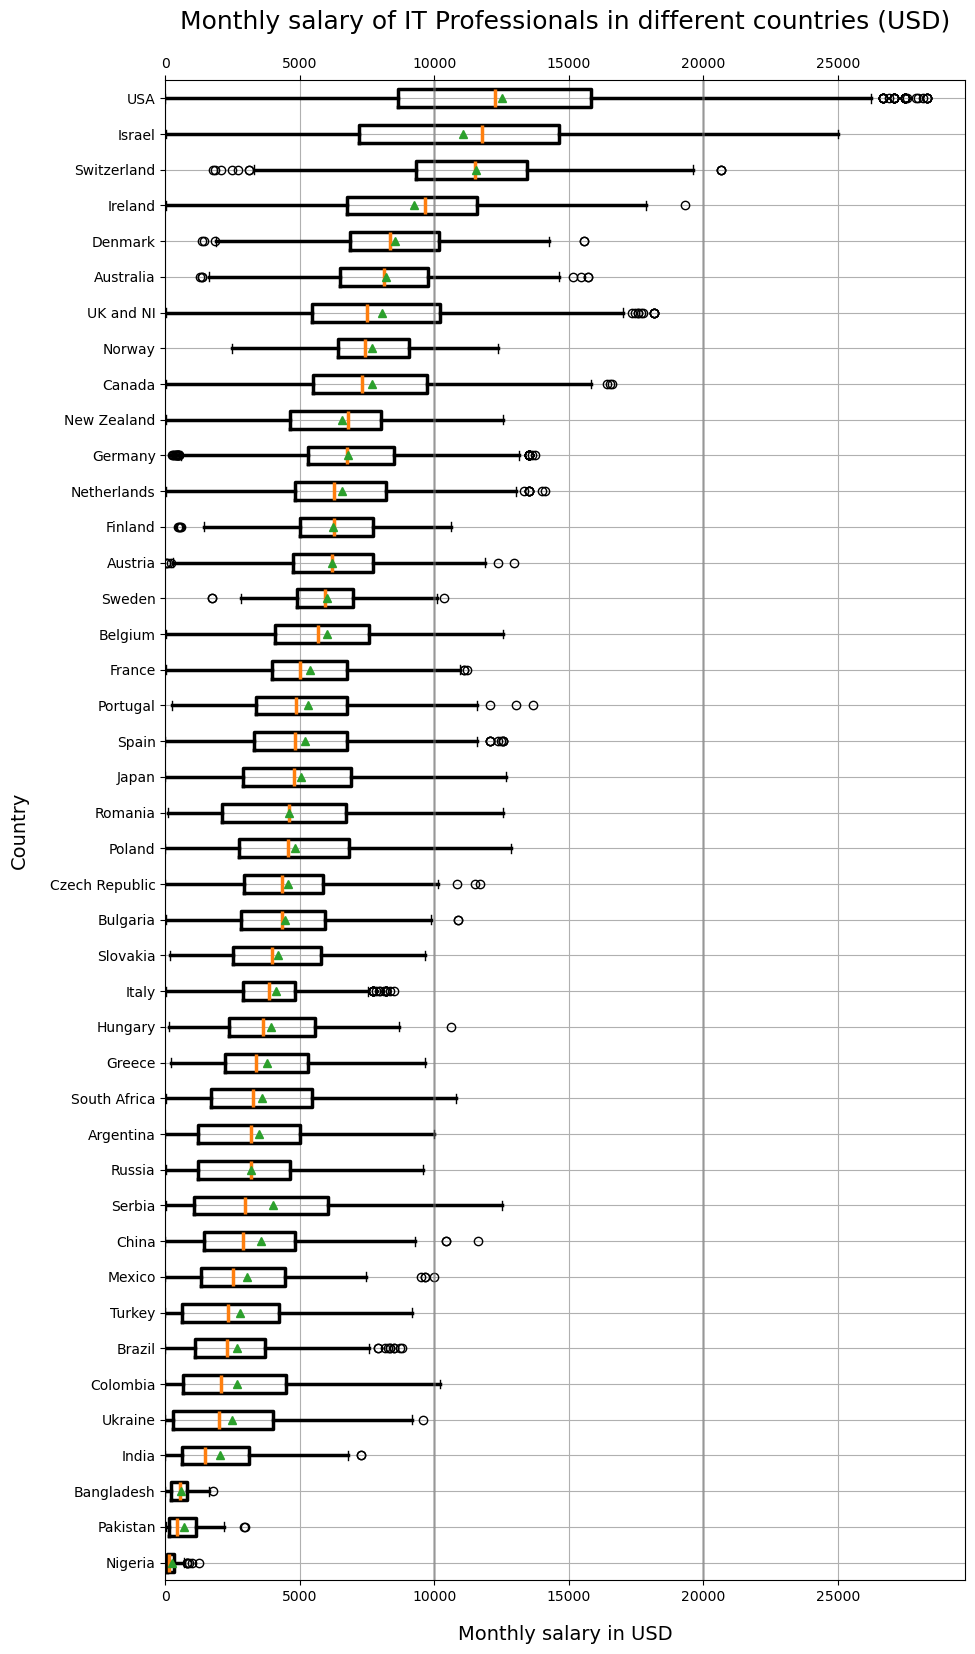

In [89]:
df_cut.boxplot(
    column = 'Salary', 
    by = 'Country', 
    figsize = (10, 20), 
    vert = False, showmeans = True, 
    color = 'black', 
    boxprops={'linewidth': 2.5}, 
    medianprops={'linewidth': 2.5}, 
    whiskerprops={'linewidth': 2.5})

plt.suptitle('')
plt.title("Monthly salary of IT Professionals in different countries (USD)", fontsize = 18, pad = 20)
plt.xlabel("Monthly salary in USD", fontsize = 14, labelpad = 15)
plt.ylabel("Country", fontsize = 14, labelpad = 15)
plt.xticks( range(0, 30000, 5000) )
plt.xlim(left = 0)
plt.tick_params('x', top = True, labeltop = True )
plt.axvline(x = 10000 , linestyle = '-', linewidth = 2, alpha = 0.5, color = 'gray')
plt.axvline(x = 20000 , linestyle = '-', linewidth = 2, alpha = 0.5, color = 'gray')

In [90]:
df_cut['OrgSize'].value_counts()

OrgSize
20 to 99 employees                                    3542
100 to 499 employees                                  3403
10,000 or more employees                              2610
Less than 20 employees                                2608
1,000 to 4,999 employees                              2313
500 to 999 employees                                  1332
5,000 to 9,999 employees                               878
Just me - I am a freelancer, sole proprietor, etc.     478
I don’t know                                           243
Name: count, dtype: int64

In [91]:
df_cut['EdLevel'].value_counts()

EdLevel
Bachelor               7592
Master                 5179
Undergrad/No degree    2002
Postgrad/PhD           1036
High School             786
Associate               595
Other                   153
Primary School           64
Name: count, dtype: int64

In [92]:
df_stats = df_cut.copy()

df_stats['OrgSize'] = df_stats['OrgSize'].str.replace(' employees', '', regex=False) \
                                         .str.replace(' to ', '-', regex=False) \
                                         .str.replace(' or more', '+', regex=False) \
                                         .str.replace('Just me - I am a freelancer, sole proprietor, etc.', 'Freelancer', regex=False)
df_stats

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,34,Master,8.00,5104.67,Ukraine,14.00,20-99,Fintech,"Yes, I use AI tools monthly or infrequently"
1,34,Associate,2.00,8701.08,Netherlands,10.00,500-999,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,44,Bachelor,4.00,3016.42,Ukraine,5.00,"10,000+",Retail and Consumer Services,"Yes, I use AI tools weekly"
3,44,Postgrad/PhD,22.00,6000.00,Ukraine,30.00,Less than 20,Software Development,"Yes, I use AI tools daily"
4,34,Bachelor,9.00,5833.33,Ukraine,15.00,"5,000-9,999",Banking/Financial Services,"Yes, I use AI tools monthly or infrequently"
...,...,...,...,...,...,...,...,...,...
18347,34,Master,4.00,6863.83,UK and NI,10.00,"1,000-4,999","Transportation, or Supply Chain","Yes, I use AI tools weekly"
18348,44,Bachelor,22.00,15666.67,USA,5.00,"10,000+",Retail and Consumer Services,"Yes, I use AI tools daily"
18349,54,Postgrad/PhD,8.00,227.42,Poland,6.00,"1,000-4,999",Software Development,"Yes, I use AI tools daily"
18350,54,Bachelor,29.00,5750.67,South Africa,29.00,100-499,Software Development,"Yes, I use AI tools daily"


In [93]:
df_stats

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,34,Master,8.00,5104.67,Ukraine,14.00,20-99,Fintech,"Yes, I use AI tools monthly or infrequently"
1,34,Associate,2.00,8701.08,Netherlands,10.00,500-999,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,44,Bachelor,4.00,3016.42,Ukraine,5.00,"10,000+",Retail and Consumer Services,"Yes, I use AI tools weekly"
3,44,Postgrad/PhD,22.00,6000.00,Ukraine,30.00,Less than 20,Software Development,"Yes, I use AI tools daily"
4,34,Bachelor,9.00,5833.33,Ukraine,15.00,"5,000-9,999",Banking/Financial Services,"Yes, I use AI tools monthly or infrequently"
...,...,...,...,...,...,...,...,...,...
18347,34,Master,4.00,6863.83,UK and NI,10.00,"1,000-4,999","Transportation, or Supply Chain","Yes, I use AI tools weekly"
18348,44,Bachelor,22.00,15666.67,USA,5.00,"10,000+",Retail and Consumer Services,"Yes, I use AI tools daily"
18349,54,Postgrad/PhD,8.00,227.42,Poland,6.00,"1,000-4,999",Software Development,"Yes, I use AI tools daily"
18350,54,Bachelor,29.00,5750.67,South Africa,29.00,100-499,Software Development,"Yes, I use AI tools daily"


In [94]:
df_stats['YearsCode'].max()

60.0

In [95]:
df_stats['OrgSize'].unique()

array(['20-99', '500-999', '10,000+', 'Less than 20', '5,000-9,999',
       '100-499', '1,000-4,999', 'Freelancer', 'I don’t know'],
      dtype=object)

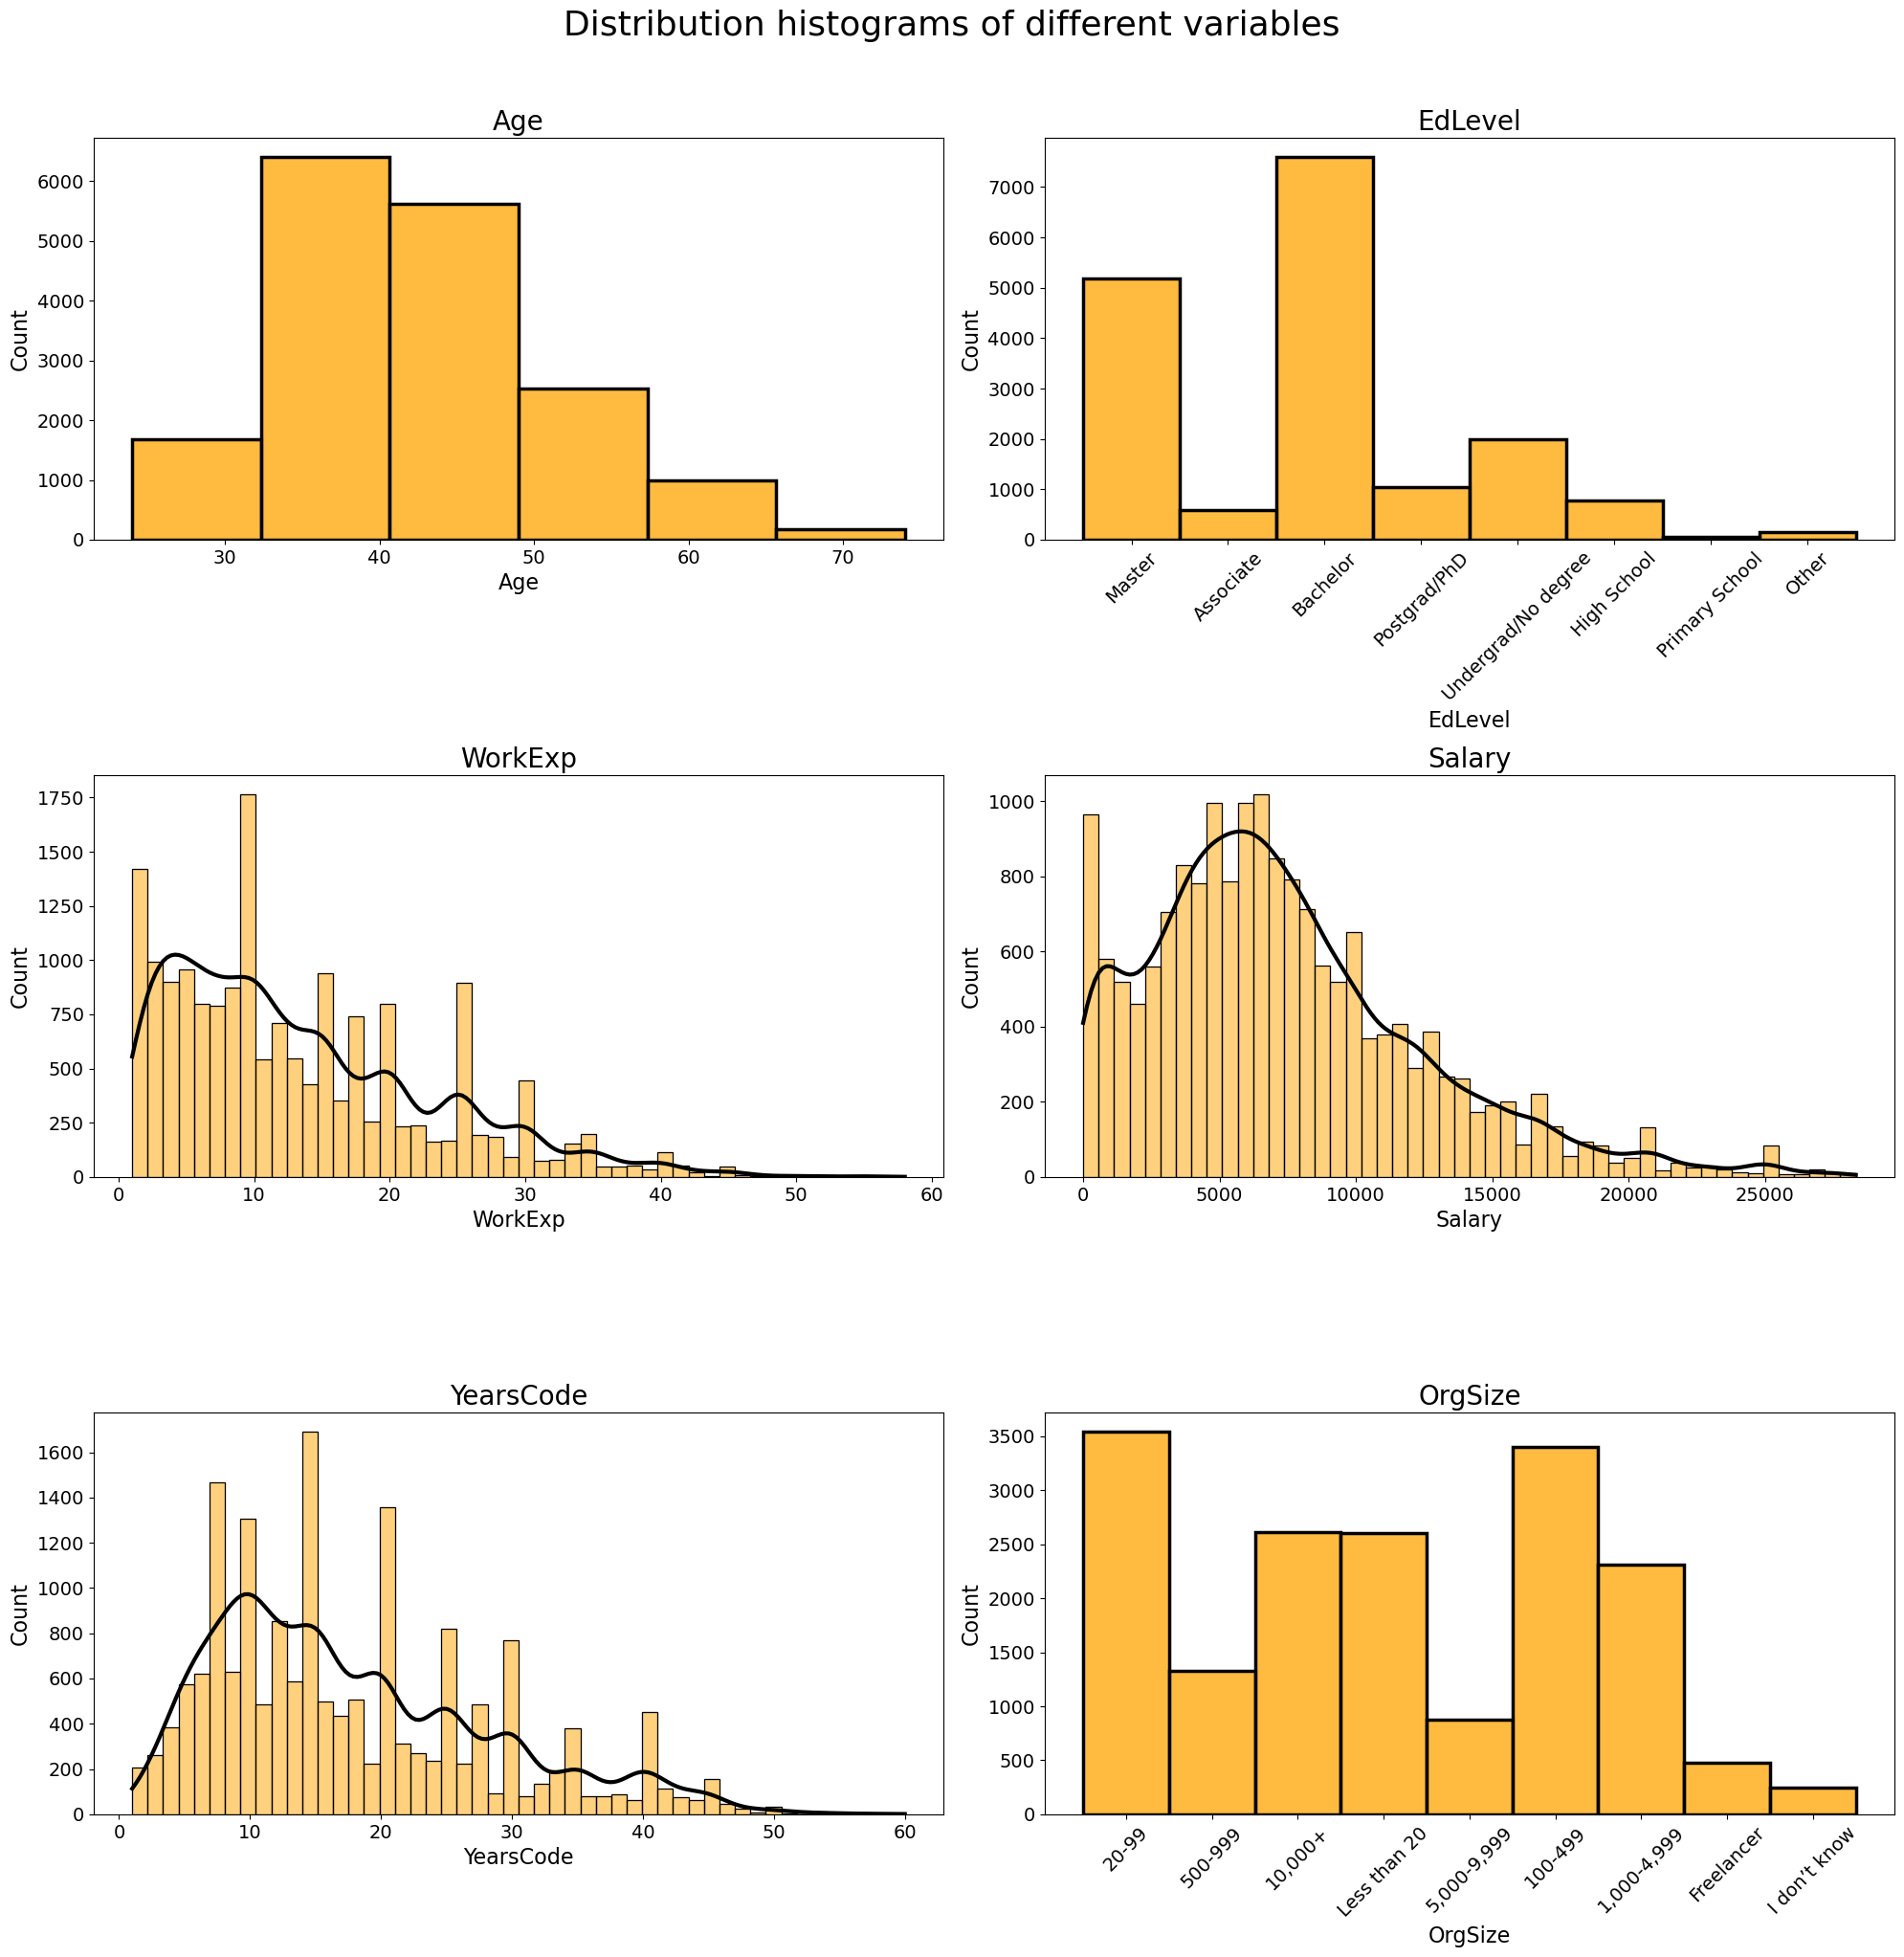

In [96]:
features = {
    'Age' : 6,
    'EdLevel' : 8,
    'WorkExp' : 50,
    'Salary' : 50,
    'YearsCode' : 50,
    'OrgSize' : 8
}

fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()

categorical = ['Age', 'EdLevel', 'OrgSize']

for i, col in enumerate(features):
    use_kde = False if col in categorical else True
    
    sns.histplot(data=df_stats, x=col, bins=features[col], ax=axes[i], kde=use_kde, color = 'orange', lw = 2.5)
    
    if use_kde:
        axes[i].lines[0].set_color('black')
        axes[i].lines[0].set_linewidth(3)
        
    if col in ['EdLevel', 'OrgSize']:
        axes[i].tick_params(axis='x', rotation=45)
        
    axes[i].tick_params(axis='both', labelsize=14)
    axes[i].set_title(f"{col}", fontsize=20)
    axes[i].set_xlabel(col, fontsize=16)
    axes[i].set_ylabel("Count", fontsize=16)

plt.suptitle("Distribution histograms of different variables", fontsize=26, y=1.02)
plt.tight_layout()

In [97]:
org_map = {
    "I don’t know": 0,
    "Freelancer": 1,
    "Less than 20": 2,
    "20-99": 3,
    "100-499": 4,
    "500-999": 5,
    "1,000-4,999": 6,
    "5,000-9,999": 7,
    "10,000+": 8
}

ed_map = {
    'Primary School': 1,
    'High School': 2,
    'Other': 3,
    'Undergrad/No degree': 4,
    'Associate': 5,
    'Bachelor': 6,
    'Master': 7,
    'Postgrad/PhD': 8
}

df_stats['OrgSize'] = df_stats['OrgSize'].replace(org_map)
df_stats['EdLevel'] = df_stats['EdLevel'].replace(ed_map)

C:\Users\Krzysiek\AppData\Local\Temp\ipykernel_7644\3466977628.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_stats['OrgSize'] = df_stats['OrgSize'].replace(org_map)
C:\Users\Krzysiek\AppData\Local\Temp\ipykernel_7644\3466977628.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_stats['EdLevel'] = df_stats['EdLevel'].replace(ed_map)


In [98]:
df_stats['Country'].value_counts()


Country
USA               4325
Germany           1798
UK and NI         1230
India              859
France             800
Canada             731
Ukraine            563
Netherlands        496
Brazil             485
Spain              452
Italy              449
Australia          440
Poland             405
Sweden             368
Switzerland        338
Czech Republic     246
Austria            235
Denmark            180
Portugal           177
Belgium            164
Romania            159
Norway             158
Mexico             155
Israel             155
Finland            154
South Africa       151
New Zealand        147
Turkey             143
Greece             137
Bulgaria           133
Hungary            129
Argentina          121
Ireland            119
Russia             108
Japan              103
Colombia           101
Pakistan            98
China               94
Serbia              84
Bangladesh          83
Slovakia            73
Nigeria             61
Name: count, dtype: int64

In [99]:
df_stats.reset_index(drop=True, inplace = True)
df_stats

,Age,EdLevel,WorkExp,Salary,Country,YearsCode,OrgSize,Industry,AISelect
0,34,7,8.00,5104.67,Ukraine,14.00,3,Fintech,"Yes, I use AI tools monthly or infrequently"
1,34,5,2.00,8701.08,Netherlands,10.00,5,Retail and Consumer Services,"Yes, I use AI tools weekly"
2,44,6,4.00,3016.42,Ukraine,5.00,8,Retail and Consumer Services,"Yes, I use AI tools weekly"
3,44,8,22.00,6000.00,Ukraine,30.00,2,Software Development,"Yes, I use AI tools daily"
4,34,6,9.00,5833.33,Ukraine,15.00,7,Banking/Financial Services,"Yes, I use AI tools monthly or infrequently"
...,...,...,...,...,...,...,...,...,...
17402,34,7,4.00,6863.83,UK and NI,10.00,6,"Transportation, or Supply Chain","Yes, I use AI tools weekly"
17403,44,6,22.00,15666.67,USA,5.00,8,Retail and Consumer Services,"Yes, I use AI tools daily"
17404,54,8,8.00,227.42,Poland,6.00,6,Software Development,"Yes, I use AI tools daily"
17405,54,6,29.00,5750.67,South Africa,29.00,4,Software Development,"Yes, I use AI tools daily"


In [100]:
selected_countries = { 'Poland', 'USA', 'UK and NI', 'Germany', 'France', 'Spain', 'China', 'Japan' }
corr_cols = [ 'Salary', 'WorkExp', 'YearsCode', 'EdLevel', 'OrgSize', 'Country' ]
df_sel_cou = df_stats[df_stats['Country'].isin(selected_countries)][corr_cols].copy()
df_sel_cou.reset_index(drop=True, inplace = True)
df_sel_cou

,Salary,WorkExp,YearsCode,EdLevel,OrgSize,Country
0,7291.67,7.00,11.00,4,4,USA
1,17083.33,19.00,15.00,7,5,USA
2,20833.33,17.00,23.00,6,4,USA
3,14583.33,24.00,26.00,6,7,USA
4,7927.67,10.00,10.00,6,6,Germany
...,...,...,...,...,...,...
9202,6416.67,5.00,8.00,6,6,USA
9203,6863.83,4.00,10.00,7,6,UK and NI
9204,15666.67,22.00,5.00,6,8,USA
9205,227.42,8.00,6.00,8,6,Poland


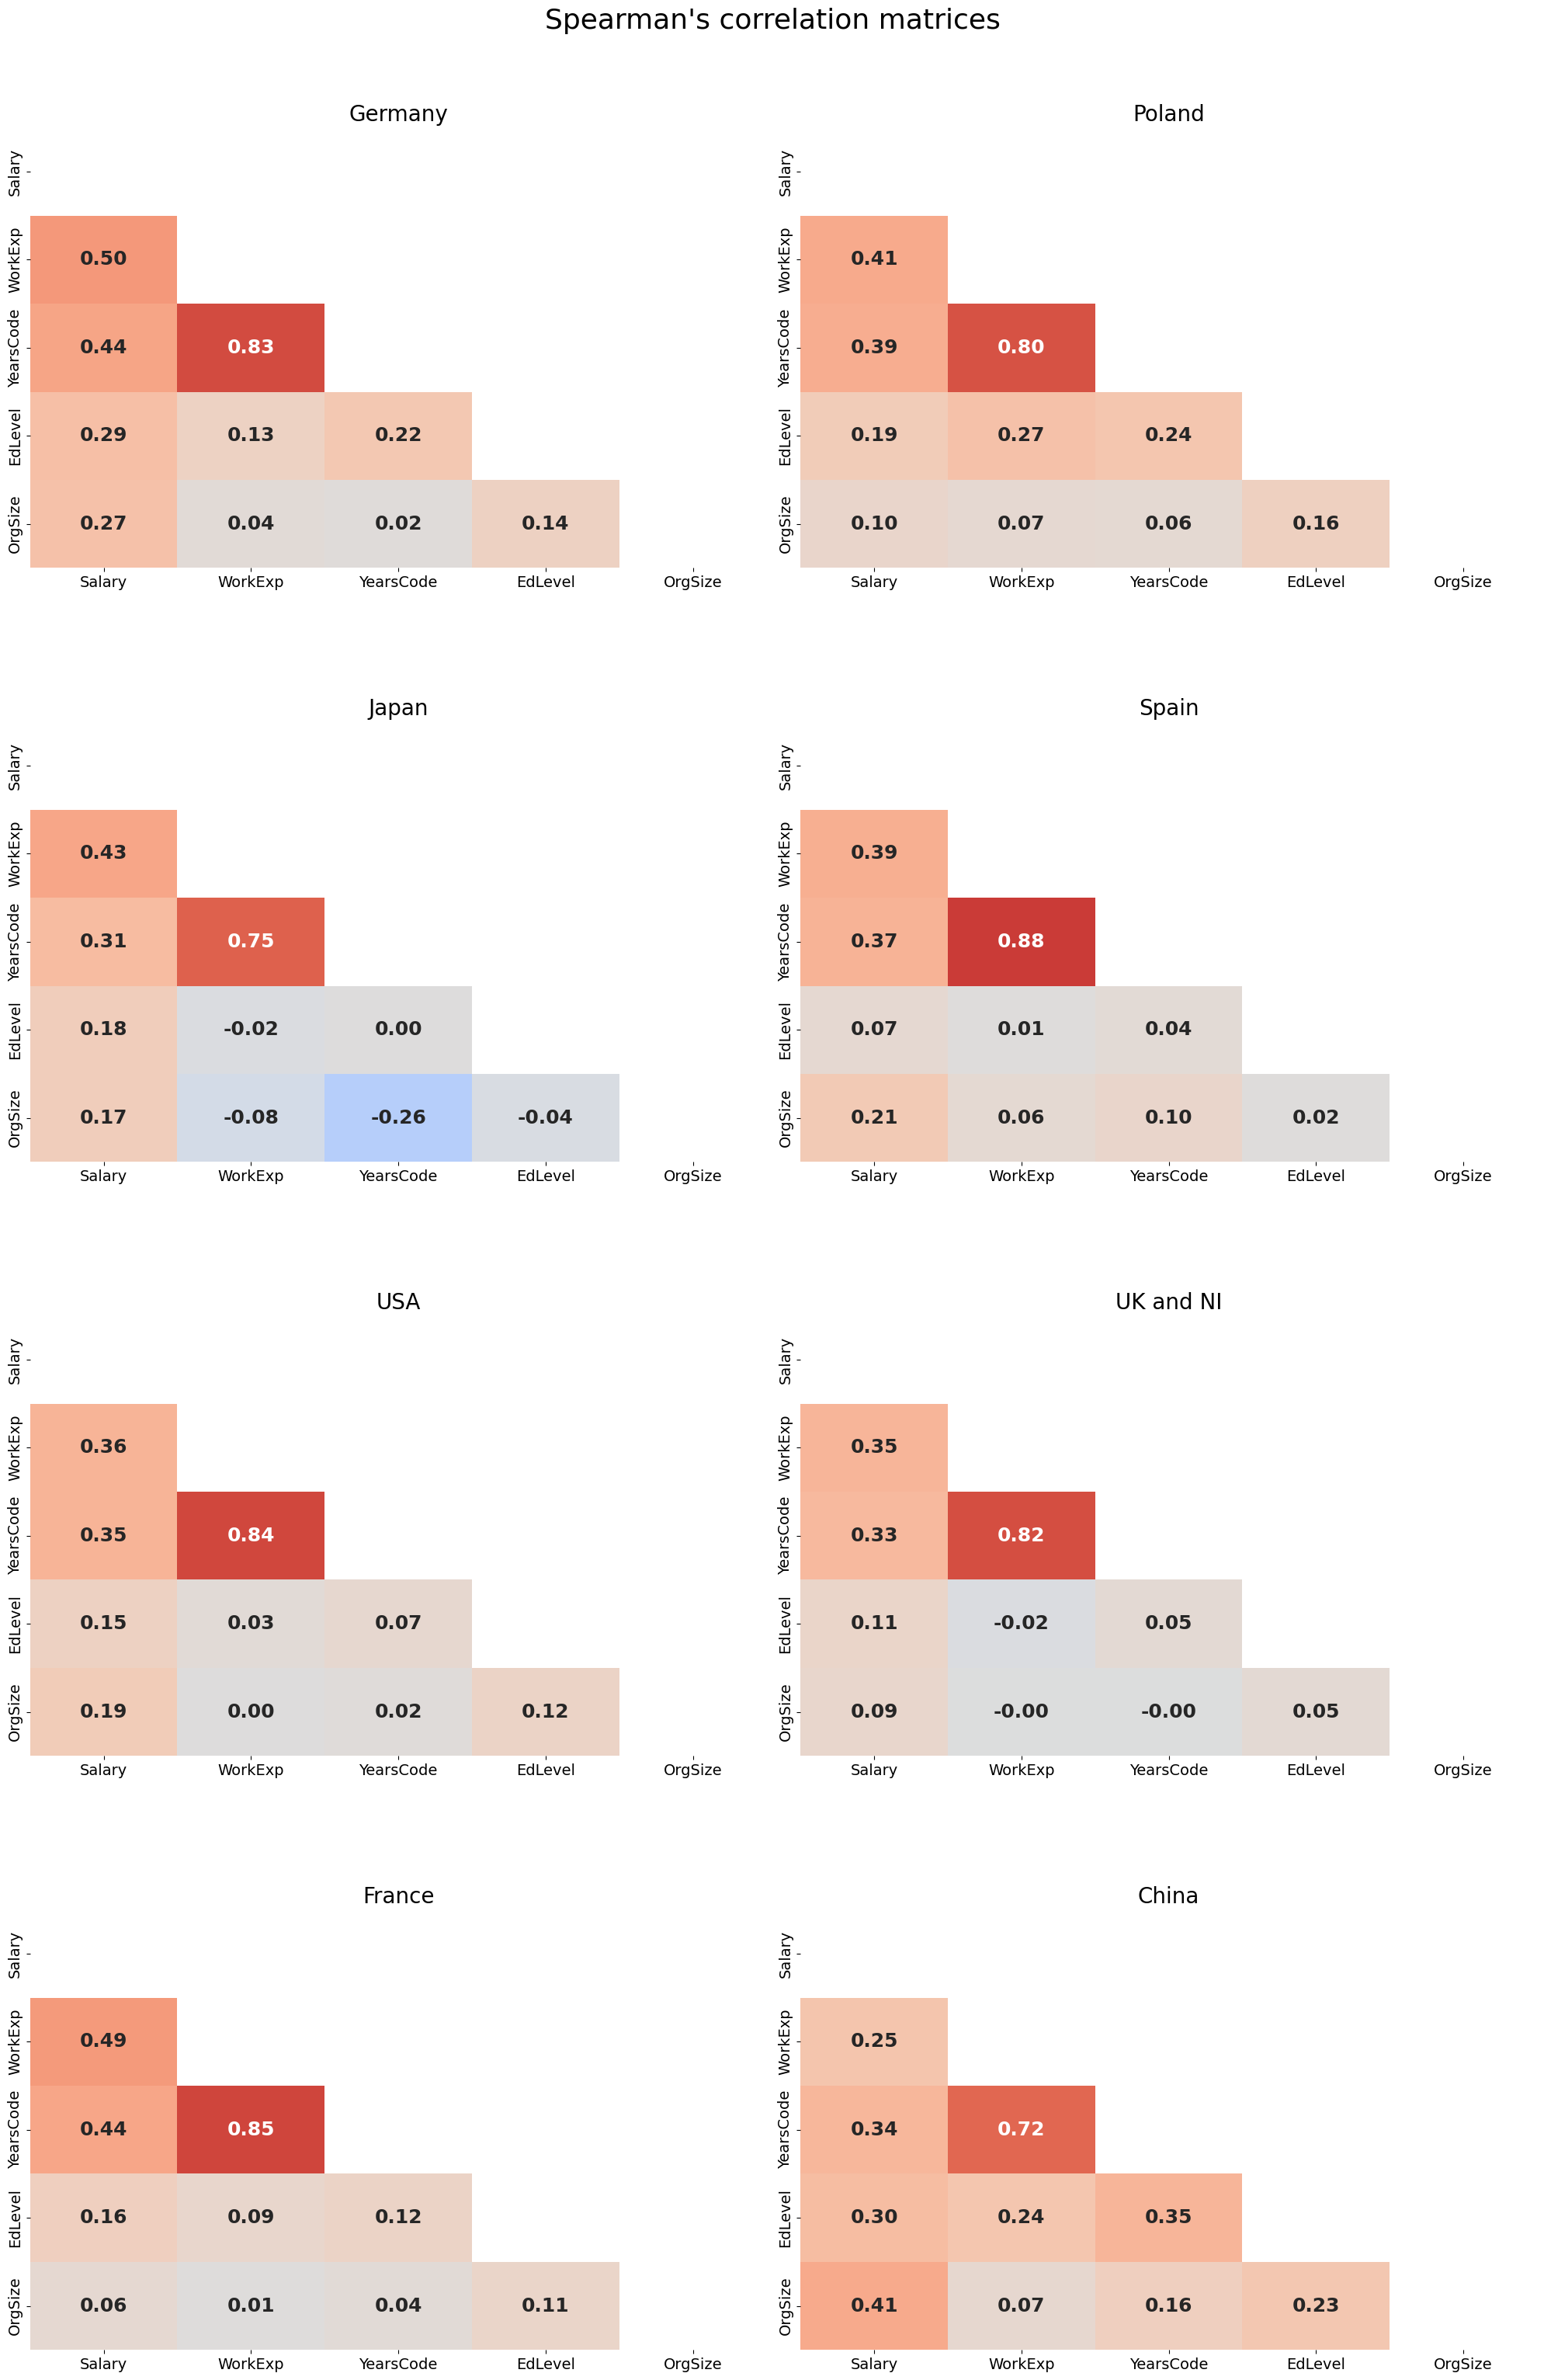

In [120]:
fig, axes = plt.subplots(4, 2, figsize = (20, 30))
axes = axes.flatten()

plt.suptitle("Spearman's correlation matrices", fontsize = 26, y=1.02)

for i, country in enumerate(selected_countries):
    data_country = df_sel_cou[df_sel_cou['Country'] == country].drop(columns='Country')
    corr_matrix = data_country.corr(method='spearman')
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                annot=True, 
                fmt=".2f", 
                cmap='coolwarm', 
                vmin=-1, 
                vmax=1, 
                center=0, 
                mask=mask, 
                ax=axes[i], 
                cbar=False,
                annot_kws = {
                    'size' : 18,
                    'weight' : 'bold'}   
               )
    
    axes[i].set_title(f"{country}", fontsize = 20)
    axes[i].tick_params(axis='both', labelsize=14)



plt.tight_layout(h_pad=10.0)
plt.show()

## 